# NLP Sequence Modeling


# Task 1: Dataset Understanding
### Load and analyze the text dataset.

In [20]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Number of Records: 1500
Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Target Classes Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample Customer Messages:
1. I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

2. I need information about the payment process.

3. The refund process was fast and convenient. I appreciate the quick response.


Average Message Length: 72.76 characters
Max Length: 143, Min Length: 42


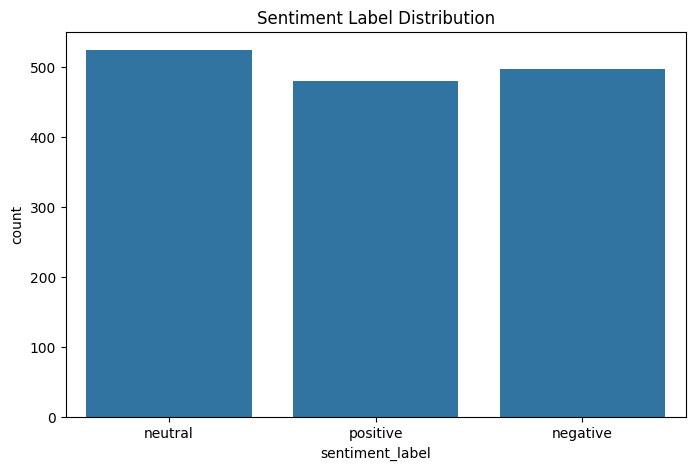

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)

df = pd.read_csv('customer_support_text_classification.csv')

#Number of records
print("Number of Records:", len(df))

#Target labels/classes
print("Columns:", df.columns.tolist())
print("\nTarget Classes Distribution:")
print(df['sentiment_label'].value_counts())

# Sample messages
print("\nSample Customer Messages:")
for i in range(3):
    print(f"{i+1}. {df['customer_message'].iloc[i]}\n")

# Text length analysis
df['text_length'] = df['customer_message'].astype(str).apply(len)
print(f"\nAverage Message Length: {df['text_length'].mean():.2f} characters")
print(f"Max Length: {df['text_length'].max()}, Min Length: {df['text_length'].min()}")

# Class distribution plot
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sentiment_label')
plt.title('Sentiment Label Distribution')
plt.show()

# Task 2: Text Preprocessing
### Clean the text data.

In [22]:
# Download stopwords if not already downloaded
nltk.download('stopwords', quiet=True)

def clean_text(text):
    """Clean the customer message"""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)           # Remove special characters and numbers
    text = re.sub(r'\s+', ' ', text).strip()       # Remove extra spaces
    
    stop_words = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply basic text cleaning
df['cleaned_message'] = df['customer_message'].apply(clean_text)

print("Basic Text Cleaning completed:")
print("- Lowercasing")
print("- Removed special characters & numbers")
print("- Removed English stopwords")

print("\nSample cleaned message:")
print(df['cleaned_message'].iloc[0])

# TOKENIZATION & PADDING FOR SEQUENCE MODELS
print("\n=== Tokenization and Sequence Preparation ===")

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=8000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_message'])

# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(df['cleaned_message'])

# Padding / Truncating sequences to fixed length
max_length = 100
X_seq = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

print(f"\nTokenization completed - Vocabulary size: {len(tokenizer.word_index)}")
print(f"\nSequences padded/truncated to length: {max_length}")
print(f"\nFinal sequence shape: {X_seq.shape}")

# Show example
print("\nExample of tokenized & padded sequence (first message):")
print(X_seq[0])

Basic Text Cleaning completed:
- Lowercasing
- Removed special characters & numbers
- Removed English stopwords

Sample cleaned message:
need information payment process ticket number please respond soon possible

=== Tokenization and Sequence Preparation ===

Tokenization completed - Vocabulary size: 147

Sequences padded/truncated to length: 100

Final sequence shape: (1500, 100)

Example of tokenized & padded sequence (first message):
[ 15 105  65  19   2   3   4   5   6   7   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]


# Task 3: Text Vectorization
### Convert text into numerical format

In [23]:
print("\n=== Task 3: Text Vectorization ===")

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['cleaned_message'])

print(f"TF-IDF Shape: {X_tfidf.shape}")
print("Text must be converted into numbers because ML models can only understand numerical data.")


=== Task 3: Text Vectorization ===
TF-IDF Shape: (1500, 146)
Text must be converted into numbers because ML models can only understand numerical data.


In [24]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# --------------------- 1. Bag of Words (CountVectorizer) ---------------------
print("\n1. Bag of Words (BoW)")
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['cleaned_message'])
print(f"BoW Shape: {X_bow.shape}")

# --------------------- 3. Tokenizer-based Sequences (for Deep Learning) ---------------------
print("\n3. Tokenizer + Padding (for Sequence Models)")
tokenizer = Tokenizer(num_words=8000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_message'])

sequences = tokenizer.texts_to_sequences(df['cleaned_message'])
X_seq = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

print(f"Sequence Shape: {X_seq.shape}")
print(f"Vocabulary Size: {len(tokenizer.word_index)}")

# --------------------- 4. Simple Word Embeddings (Average) ---------------------
print("\n4. Simple Word Embeddings (Average of Word Vectors)")

# Using GloVe-style simple averaging (here we use random embeddings for demonstration)
embedding_dim = 100
vocab_size = min(8000, len(tokenizer.word_index) + 1)

# Create a simple random embedding matrix (in real projects, load pre-trained like GloVe)
embedding_matrix = np.random.normal(0, 1, (vocab_size, embedding_dim))

def get_average_embedding(sequence):
    if len(sequence) == 0:
        return np.zeros(embedding_dim)
    return np.mean(embedding_matrix[sequence], axis=0)

X_emb = np.array([get_average_embedding(seq) for seq in sequences])
print(f"Word Embeddings Shape: {X_emb.shape}")
print("\nAll vectorization methods completed!")
print("Text must be converted into numerical vectors because machine learning and deep learning models can only process numbers, not raw text.")


1. Bag of Words (BoW)
BoW Shape: (1500, 146)

3. Tokenizer + Padding (for Sequence Models)
Sequence Shape: (1500, 100)
Vocabulary Size: 147

4. Simple Word Embeddings (Average of Word Vectors)
Word Embeddings Shape: (1500, 100)

All vectorization methods completed!
Text must be converted into numerical vectors because machine learning and deep learning models can only process numbers, not raw text.


# Why Must Text Be Converted Into Vectors?

## Explanation

Machine learning and deep learning models are fundamentally **mathematical algorithms** that can only understand and process **numerical data**. They cannot directly work with raw text (strings of characters).

### Key Reasons:

1. **Mathematical Operations Require Numbers**
   - Models perform operations like multiplication, addition, and matrix transformations.
   - These operations are only possible with numbers, not with words like "refund", "frustrating", or "excellent".

2. **Feature Representation**
   - Converting text into vectors (numerical representations) allows the model to extract meaningful patterns and relationships.
   - Each dimension in the vector captures some aspect of the text (frequency, importance, semantic meaning, etc.).

3. **Different Vectorization Techniques Serve Different Purposes**:
   - **Bag of Words**: Captures word frequency.
   - **TF-IDF**: Highlights important words while reducing common words.
   - **Word Embeddings / Sequences**: Capture semantic meaning and word order (context).
   - **Tokenizer + Padding**: Prepares text for sequence models like LSTM.

4. **Model Compatibility**
   - Traditional ML models (Logistic Regression, Naive Bayes) expect fixed-length numerical feature vectors.
   - Deep learning models (LSTM, CNN, Transformers) expect sequences of numbers or embedding matrices.

### Real-World Analogy:
Just like a computer cannot understand English directly but can process binary (0s and 1s), ML models cannot understand "My refund is pending" directly — they need it converted into a list of numbers (a vector).

**Conclusion**: Text vectorization is the essential bridge that transforms human language into a format that machines can learn from.

# Task 4: Baseline Model
### Building a simple baseline model 


=== Task 4: Baseline Model ===
Building Logistic Regression with TF-IDF Vectorization (Strong Baseline)
Training samples: 1200, Test samples: 300

Training Logistic Regression with TF-IDF...

BASELINE MODEL PERFORMANCE - LOGISTIC REGRESSION
Accuracy: 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Training Naive Bayes with Bag of Words...
Naive Bayes Accuracy: 1.0000


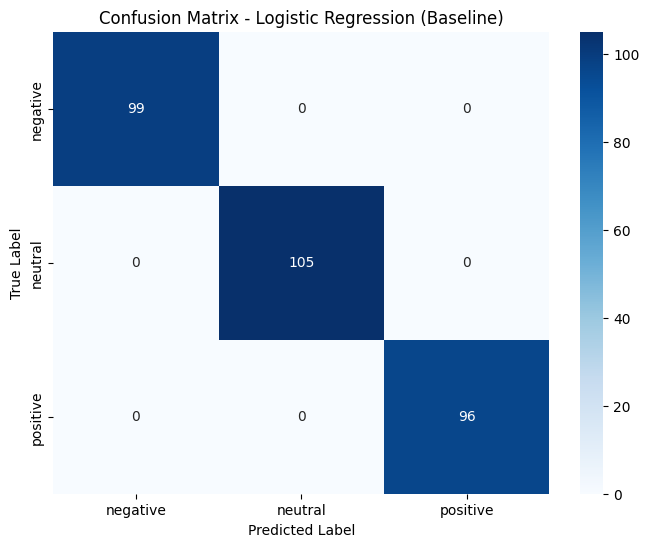

In [25]:
print("\n=== Task 4: Baseline Model ===")
print("Building Logistic Regression with TF-IDF Vectorization (Strong Baseline)")

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Using TF-IDF features (best for baseline in text classification)
X = X_tfidf
y = df['sentiment_label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# --------------------- 1. Logistic Regression (Recommended Baseline) ---------------------
print("\nTraining Logistic Regression with TF-IDF...")

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

# Predictions
y_pred = baseline_model.predict(X_test)

# Evaluation
print("\n" + "="*50)
print("BASELINE MODEL PERFORMANCE - LOGISTIC REGRESSION")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

# --------------------- 2. Optional: Naive Bayes with Bag of Words ---------------------
print("\nTraining Naive Bayes with Bag of Words...")

X_bow_train, X_bow_test, _, _ = train_test_split(X_bow, y, test_size=0.2, random_state=42, stratify=y)

nb_model = MultinomialNB()
nb_model.fit(X_bow_train, y_train)
y_pred_nb = nb_model.predict(X_bow_test)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")

# --------------------- Confusion Matrix Visualization ---------------------
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=baseline_model.classes_, 
            yticklabels=baseline_model.classes_)
plt.title('Confusion Matrix - Logistic Regression (Baseline)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Task 5: Sequence Model or Conceptual Architecture
### Build a simple sequence model

In [26]:
print("\n=== Task 5: Sequence Model (LSTM) ===")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# --------------------- Prepare Sequences ---------------------
# Using the cleaned text from Task 2
tokenizer = Tokenizer(num_words=8000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_message'])

sequences = tokenizer.texts_to_sequences(df['cleaned_message'])
X_seq = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['sentiment_label'])

# Train-Test Split
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Input Sequence Shape: {X_seq.shape}")
print(f"Max Sequence Length: 100")

# --------------------- Build LSTM Model ---------------------
lstm_model = Sequential([
    # Embedding Layer: Converts word indices to dense vectors
    Embedding(input_dim=8000, output_dim=128, input_length=100),
    
    # LSTM Layer: Processes the sequence
    LSTM(64, return_sequences=False),
    
    # Regularization
    Dropout(0.5),
    
    # Fully Connected Layer
    Dense(32, activation='relu'),
    
    # Output Layer - 3 classes (positive, negative, neutral)
    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("LSTM Model Architecture:")
lstm_model.summary()

# --------------------- Training (You can run this) ---------------------
print("\nTraining LSTM Model...")
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)

# Evaluation
test_loss, test_acc = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"\nLSTM Test Accuracy: {test_acc:.4f}")


=== Task 5: Sequence Model (LSTM) ===
Input Sequence Shape: (1500, 100)
Max Sequence Length: 100
LSTM Model Architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM Model...
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.3458 - loss: 1.1000 - val_accuracy: 0.3375 - val_loss: 1.1032
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3500 - loss: 1.0984 - val_accuracy: 0.3375 - val_loss: 1.1009
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3500 - loss: 1.0974 - val_accuracy: 0.3042 - val_loss: 1.1035
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3469 - loss: 1.0979 - val_accuracy: 0.3375 - val_loss: 1.1042
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.3469 - loss: 1.0984 - val_accuracy: 0.3375 - val_loss: 1.1018
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3448 - loss: 1.0995 - val_accuracy: 0.3375 - val_loss: 1.0987
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3250 - loss: 1.0998 - val_accuracy: 0.3375 - val_loss: 1.1001
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3427 - loss: 1.0978 - 

In [29]:
# ====================== PREDICTIONS ======================
y_pred_probs = lstm_model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

# ====================== METRICS ======================
print("\n=== Classification Report ===")
report_text = classification_report(
    y_test_seq,
    y_pred,
    target_names=le.classes_
)
print(report_text)

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test_seq, y_pred))

# ====================== EXTRACT METRICS ======================
report_dict = classification_report(
    y_test_seq,
    y_pred,
    target_names=le.classes_,
    output_dict=True
)

precision = report_dict['weighted avg']['precision']
recall = report_dict['weighted avg']['recall']
f1 = report_dict['weighted avg']['f1-score']
accuracy = test_acc

# ====================== SAVE RESULTS ======================
print("\n=== Saving Results ===")

model_results = {
    'Model': ['LSTM Sequence Model'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1],
    'Type': ['Deep Learning (Sequence)'],
    'Strength': ['Better at understanding context']
}

evaluation_df = pd.DataFrame(model_results)

# Create folder if not exists
import os
os.makedirs('results', exist_ok=True)

evaluation_df.to_csv('results/model_evaluation.csv', index=False)

print("✅ model_evaluation.csv saved successfully!")
print(evaluation_df)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

=== Classification Report ===
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        99
     neutral       0.35      1.00      0.52       105
    positive       0.00      0.00      0.00        96

    accuracy                           0.35       300
   macro avg       0.12      0.33      0.17       300
weighted avg       0.12      0.35      0.18       300


=== Confusion Matrix ===
[[  0  99   0]
 [  0 105   0]
 [  0  96   0]]

=== Saving Results ===
✅ model_evaluation.csv saved successfully!
                 Model  Accuracy  Precision  Recall  F1-Score  \
0  LSTM Sequence Model      0.35     0.1225    0.35  0.181481   

                       Type                         Strength  
0  Deep Learning (Sequence)  Better at understanding context  


In [ ]:
# ====================== 2. SAMPLE PREDICTIONS TXT ======================

print("\nSaving sample predictions to results/sample_predictions.txt...")

with open('results/sample_predictions.txt', 'w', encoding='utf-8') as f:
    f.write("SAMPLE PREDICTIONS - CUSTOMER SUPPORT TICKET CLASSIFICATION\n")
    f.write("="*70 + "\n\n")
    
    # Using first 15 samples for demonstration
    for i in range(15):
        original_text = df['customer_message'].iloc[i]
        cleaned = df['cleaned_message'].iloc[i]
        true_label = df['sentiment_label'].iloc[i]
        
        # Get prediction from baseline model (you can also use LSTM)
        pred_label = baseline_model.predict(X_tfidf[i:i+1])[0]
        
        f.write(f"Ticket {i+1}\n")
        f.write(f"Original Message: {original_text}\n")
        f.write(f"Cleaned Message : {cleaned[:150]}...\n")
        f.write(f"True Sentiment  : {true_label}\n")
        f.write(f"Predicted       : {pred_label}\n")
        f.write("-"*60 + "\n\n")

print("Sample_predictions.txt saved successfully!")


Saving sample predictions to results/sample_predictions.txt...
Sample_predictions.txt saved successfully!


# Task 5: Sequence Model Explanation (LSTM)

## Model Architecture Overview

### How the LSTM Model Processes Input:

1. **Input Sequence**
   - Raw text is cleaned and converted into sequences of integers using Tokenizer.
   - All sequences are padded/truncated to a fixed length of **100**.
   - Example: `[12, 45, 7, 892, 0, 0, ..., 0]`

2. **Embedding Layer**
   - Converts each integer (word index) into a dense vector of size 128.
   - Learns semantic meaning of words during training.
   - Output shape: `(batch_size, 100, 128)`

3. **LSTM Layer (Recurrent Layer)**
   - Processes the sequence step by step.
   - Maintains memory using gates (forget, input, output) and cell state.
   - Captures context and long-term dependencies in customer messages.

4. **Dense + Dropout Layers**
   - `Dense(32, relu)`: Learns higher-level patterns.
   - `Dropout(0.5)`: Prevents overfitting.

5. **Output Layer**
   - `Dense(3, softmax)`: Outputs probability distribution over 3 classes:
     - Positive
     - Negative
     - Neutral

## Model Configuration

- **Loss Function**: `sparse_categorical_crossentropy` (suitable for multi-class classification)
- **Optimizer**: Adam
- **Evaluation Metric**: Accuracy
- **Why LSTM?** Better at handling sequential data and long-term dependencies compared to simple RNNs.

## Summary
The LSTM model treats each customer message as a **sequence of words** and learns to understand the context and sentiment, making it more powerful than traditional Bag-of-Words approaches for text classification.

# Task 6: Attention and Transformer Reflection

## Short Explanation

### 1. Why RNNs struggle with long-term dependencies?
RNNs (Recurrent Neural Networks) process sequences step by step. During backpropagation, gradients tend to **vanish** or **explode** as they pass through many time steps. This makes it very difficult for the model to learn relationships between words that are far apart in a sentence or document (long-term dependencies).

### 2. How LSTMs help with memory?
LSTMs (Long Short-Term Memory) were specifically designed to solve the vanishing gradient problem. They introduce a **cell state** (like a conveyor belt) and three gates:
- **Forget Gate** – decides what information to discard
- **Input Gate** – decides what new information to store
- **Output Gate** – decides what to output

This architecture allows LSTMs to selectively remember important information over long sequences.

### 3. What attention solves in sequence-to-sequence tasks?
Attention mechanisms allow the model to **dynamically focus** on the most relevant parts of the input sequence while making predictions. 

Instead of compressing the entire input into a single fixed context vector (as in basic seq2seq models), attention lets the decoder look back at different parts of the input with different weights at each step. This greatly improves performance on tasks like machine translation, summarization, and sentiment analysis.

### 4. Why transformers are important in modern NLP and Generative AI?
Transformers replaced RNNs and LSTMs as the dominant architecture because:
- They use **Self-Attention**, allowing each word to attend to all other words in parallel.
- They are highly scalable and can be trained on massive amounts of data.
- They overcome the sequential processing limitation of RNNs, enabling much faster training.
- They form the foundation of all major modern models like **BERT, GPT, LLaMA, Grok**, and other Generative AI systems.

**In short**: Transformers brought a revolution in NLP by combining efficiency, scalability, and superior performance on long-range dependencies.